# Partie 1 – Exploration du corpus

1) Charger les données CSV

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
df =pd.read_csv('../data/smart_reviews_raw.csv')

2) Combien d'avis contient le dataset ?

In [7]:
df.head()

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr


In [6]:
df.shape[0]

1200

3) Combien de colonnes possède-t-il ?

In [8]:
df.shape[1]

8

4) Quel est le type de chaque colonne ?

In [10]:
print(df.dtypes)

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object


5) Existe-t-il des valeurs manquantes ?

In [11]:
print(df.isnull().sum())

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64


6) Identifier quelques types de texte en affichant par exemple : texte normal ; texte vide ; texte
contenant une URL ; texte contenant une mention ; texte contenant un hashtag ; texte
contenant des emojis ; texte avec beaucoup de ponctuation ; texte en majuscules ; texte avec
répétition de caractères.

In [12]:
# texte normal
print(df[df['texte'].notna()]['texte'].iloc[0])
# texte vide
print(df[df['texte'].isna()][['id_avis', 'texte']].head(3))
# texte contenant une URL
mask = df['texte'].str.contains('http', case=False, na=False)
print(df[mask]['texte'].iloc[0])
# texte contenant une mention
mask = df['texte'].str.contains('@', na=False)
print(df[mask]['texte'].iloc[0])
# texte contenant un hashtag
mask = df['texte'].str.contains('#', na=False)
print(df[mask]['texte'].iloc[0])
# texte contenant des emojis
import re
emoji_pattern = re.compile('[\U0001F300-\U0001FAFF\u2600-\u27BF]')
mask = df['texte'].apply(lambda x: bool(emoji_pattern.search(x)) if isinstance(x, str) else False)
print(df[mask]['texte'].iloc[0])
# texte avec beaucoup de ponctuation
mask = df['texte'].apply(lambda x: isinstance(x, str) and sum(1 for c in x if c in '!?.,;:') >= 4)
print(df[mask]['texte'].iloc[0])
# texte en majuscules
mask = df['texte'].apply(lambda x: isinstance(x, str) and x.isupper())
print(df[mask]['texte'].iloc[0])
# texte avec répétition de caractères
mask = df['texte'].apply(lambda x: bool(re.search(r'(.)\1{2,}', x)) if isinstance(x, str) else False)
print(df[mask]['texte'].iloc[0])

Très  bonne  expérience,  simple  et  efficace.
    id_avis texte
46   AV0047   NaN
108  AV0109   NaN
310  AV0311   NaN
Produit parfait, rien à signaler. https://example.com/commande/17
@client Livraison rapide et produit conforme à mes attentes.
Très satisfait de mon achat 👍 #avis
Très satisfait de mon achat 👍 #avis
Produit excellent, je suis très satisfait. !!!
LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.
Produit excellent, je suis très satisfait. !!!


7) Mesurer la longueur des textes en créant une nouvelle colonne « longueur » pour déterminer :
longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles.

In [13]:
df['longueur'] = df['texte'].apply(lambda x: len(x) if isinstance(x, str) else 0)
non_vide = df[df['texte'].notna()]

print('min :', non_vide['longueur'].min())
print('max :', non_vide['longueur'].max())
print('moyenne :', round(non_vide['longueur'].mean(), 1))
print('médiane :', non_vide['longueur'].median())
print('Q1 :', non_vide['longueur'].quantile(0.25))
print('Q3 :', non_vide['longueur'].quantile(0.75))

min : 2
max : 636
moyenne : 49.2
médiane : 48.0
Q1 : 37.0
Q3 : 56.0


8) Visualiser la distribution de la longueur des avis puis répondre aux questions

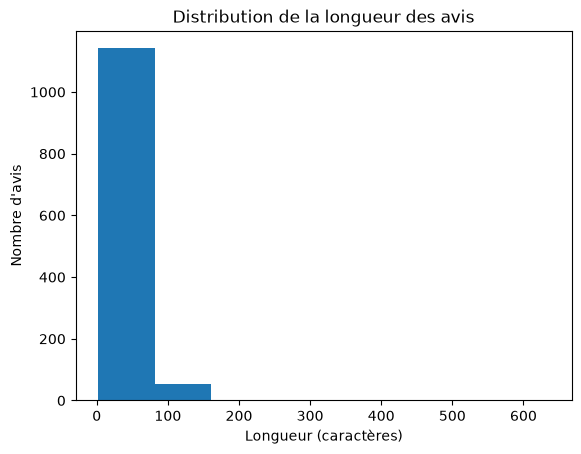

In [15]:
plt.hist(non_vide['longueur'], bins=8)
plt.xlabel('Longueur (caractères)')
plt.ylabel("Nombre d'avis")
plt.title('Distribution de la longueur des avis')
plt.show()

a) Existe-t-il des textes anormalement longs ?

In [16]:
q3 = non_vide['longueur'].quantile(0.75)
iqr = q3 - non_vide['longueur'].quantile(0.25)
seuil_haut = q3 + 1.5 * iqr
print('seuil :', seuil_haut)
print('nb textes anormalement longs :', (non_vide['longueur'] > seuil_haut).sum())

seuil : 84.5
nb textes anormalement longs : 41


b) Existe-t-il beaucoup de textes très courts ?

In [17]:
print('nb textes < 10 caractères :', (non_vide['longueur'] < 10).sum())
print(non_vide[non_vide['longueur'] < 10]['texte'].tolist())

nb textes < 10 caractères : 4
['OK', 'Pas bon', 'OK', '   ']


9) Détecter les textes vides

In [18]:
vides = df[df['texte'].isna() | (df['texte'].str.strip() == '')]
print(len(vides))

6


10) Détecter les doublons sur le texte

In [19]:
print(df.duplicated(subset='texte').sum())

881


11) Les classes sont-elles équilibrées ?

In [20]:
print(df['sentiment'].value_counts(normalize=True).round(3) * 100)

sentiment
positif    64.7
neutre     20.5
negatif    14.8
Name: proportion, dtype: float64


Non, les classes sont déséquilibrées.

12) Quelle est la classe majoritaire ?

In [21]:
print(df['sentiment'].value_counts().idxmax())

positif


13) Quelles métriques de classification à envisager d’utiliser ?

Avec un tel déséquilibre, l'accuracy seule serait trompeuse (prédire toujours "positif" donnerait déjà ~65% de bonnes réponses)
. Il vaut mieux utiliser le F1-score macro, la matrice de confusion, et le F1 par classe (pour surveiller la classe minoritaire "negatif").

14) Détecter les caractères particuliers : emojis ; URLs ; hashtags ; mentions ; chiffres ; caractères
spéciaux ; ponctuation répétée ; …

In [22]:
n = len(df)
has_url = df['texte'].str.contains(r'http\S+', na=False).sum()
has_mention = df['texte'].str.contains(r'@\w+', na=False).sum()
has_hashtag = df['texte'].str.contains(r'#\w+', na=False).sum()
has_digits = df['texte'].str.contains(r'\d', na=False).sum()
has_rep_punct = df['texte'].str.contains(r'([!?.])\1{1,}', na=False, regex=True).sum()

print('URLs :', has_url)
print('Mentions :', has_mention)
print('Hashtags :', has_hashtag)
print('Chiffres :', has_digits)
print('Ponctuation répétée :', has_rep_punct)

URLs : 143
Mentions : 128
Hashtags : 127
Chiffres : 142
Ponctuation répétée : 141


C:\Users\DELL\AppData\Local\Temp\ipykernel_6272\3955467779.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  has_rep_punct = df['texte'].str.contains(r'([!?.])\1{1,}', na=False, regex=True).sum()


15) Visualiser et commenter nombre d'avis par source

source
réseaux_sociaux    251
email              247
sav                239
web                232
mobile             230
WEB                  1
Name: count, dtype: int64


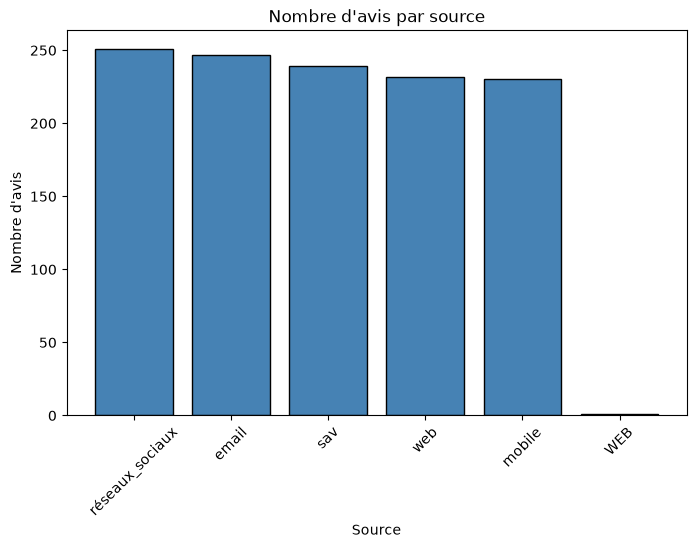

In [24]:
print(df['source'].value_counts())


counts_source = df['source'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(counts_source.index, counts_source.values, color='steelblue', edgecolor='black')
plt.xlabel('Source')
plt.ylabel("Nombre d'avis")
plt.title("Nombre d'avis par source")
plt.xticks(rotation=45)
plt.show()

Commentaire : les 5 sources principales sont équilibrées (~230-250 avis chacune). On remarque "WEB" en majuscules avec 1 seule ligne — c'est une incohérence de casse (doublon de "web") à corriger, pas une vraie 6ᵉ source.

16) Visualiser et commenter le nombre d'avis par produit

produit
Écouteurs AirSound     218
Ordinateur NovaBook    217
SmartPhone X           201
SmartWatch Pro         193
Tablette TabPlus       187
SmartPhone Y           184
Name: count, dtype: int64


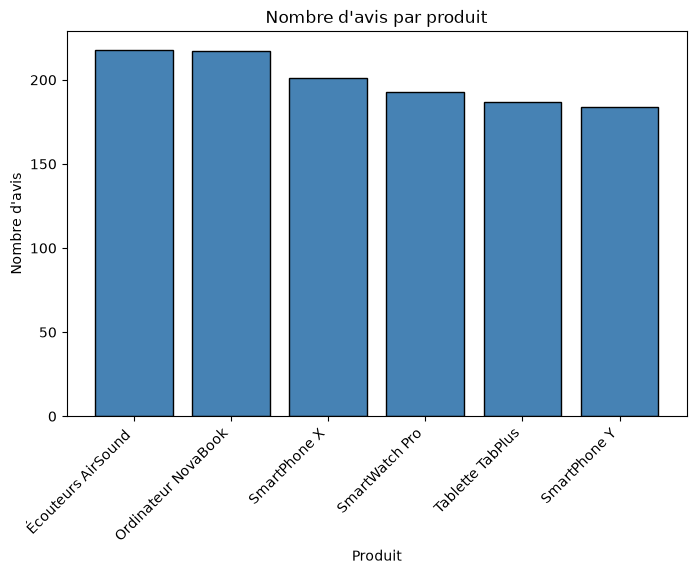

In [26]:
print(df['produit'].value_counts())


counts_produit = df['produit'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(counts_produit.index, counts_produit.values, color='steelblue', edgecolor='black')
plt.xlabel('Produit')
plt.ylabel("Nombre d'avis")
plt.title("Nombre d'avis par produit")
plt.xticks(rotation=45, ha='right')
plt.show()

Commentaire : les 6 produits sont couverts de façon homogène (184 à 218 avis), aucun n'est sous-représenté.

# Partie 2 – Nettoyage

1) Supprimer les lignes contenant des valeurs manquantes de texte

In [27]:
df = df[df['texte'].notna()]
df = df[df['texte'].str.strip() != '']   # les textes "   " comptent comme vides
print(len(df))

1194


2) Supprimer les doublons

In [28]:
df = df.drop_duplicates(subset='texte')
print(len(df))

317


3) Supprimer les URLs

In [31]:
import re
df['texte_clean'] = df['texte'].apply(lambda t: re.sub(r'http\S+|www\.\S+', '', t))


4) Traiter les mentions et hashtags avec la stratégie la plus pertinente pour une classification de
sentiment

In [32]:
mentions = set()
for t in df['texte']:
    mentions.update(re.findall(r'@\w+', t))
print(mentions)

{'@client', '@support'}


In [33]:
hashtags = set()
for t in df['texte']:
    hashtags.update(re.findall(r'#\w+', t))
print(hashtags)

{'#déception', '#avis'}


5) Nettoyer les espaces

In [34]:
df['texte_clean'] = df['texte_clean'].apply(lambda t: re.sub(r'\s+', ' ', t).strip())

6) Traiter la ponctuation avec la stratégie la plus pertinente pour une classification de sentiment

In [35]:
df['texte_clean'] = df['texte_clean'].apply(lambda t: re.sub(r'([!?])\1+', r'\1', t))
df['texte_clean'] = df['texte_clean'].apply(
    lambda t: re.sub(r'[^\w\s!?àâäéèêëïîôùûüçÀÂÄÉÈÊËÏÎÔÙÛÜÇ]', ' ', t)
)
df['texte_clean'] = df['texte_clean'].apply(lambda t: re.sub(r'\s+', ' ', t).strip())

7) Créer une fonction de nettoyage pour automatiser les actions ci-dessus

In [36]:
def nettoyer_texte(texte):
    texte = str(texte)
    texte = re.sub(r'http\S+|www\.\S+', '', texte)
    texte = re.sub(r'@\w+', '', texte)
    texte = re.sub(r'#(\w+)', r'\1', texte)
    texte = re.sub(r'([!?])\1+', r'\1', texte)
    texte = re.sub(r'[^\w\s!?àâäéèêëïîôùûüçÀÂÄÉÈÊËÏÎÔÙÛÜÇ]', ' ', texte)
    texte = re.sub(r'\s+', ' ', texte).strip()
    return texte

8) Stocker sur une colonne texte_clean, les textes ayant subi les traitements ci-dessus

In [37]:
df['texte_clean'] = df['texte'].apply(nettoyer_texte)

9) Vérifier le contenu des colonnes texte et texte_clean sur les 10 premières observations

In [38]:
print(df[['texte', 'texte_clean']].head(10))

                                               texte  \
0    Très  bonne  expérience,  simple  et  efficace.   
1                Très satisfait de mon achat 👍 #avis   
2              Produit  parfait,  rien  à  signaler.   
3     Produit excellent, je suis très satisfait. !!!   
4  LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...   
5                    Très satisfait de mon achat 👍 😊   
6  SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...   
7                 Très  satisfait  de  mon  achat  👍   
8  Le  produit  correspond  globalement  à  la  d...   
9  @client Livraison rapide et produit conforme à...   

                                         texte_clean  
0           Très bonne expérience simple et efficace  
1                   Très satisfait de mon achat avis  
2                    Produit parfait rien à signaler  
3         Produit excellent je suis très satisfait !  
4  LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST...  
5                        Très satisfait de mon achat 

# Partie 3 – Tokenisation

1) Pourquoi split() n'est-il pas suffisant pour une vraie application NLP ?

split() ne découpe que sur les espaces. Il échoue sur des cas fréquents : il ne sépare pas la ponctuation collée à un mot ("content!" reste un seul token), et il ne gère pas les contractions françaises ("l'écran"). Un tokenizer comme celui de NLTK applique des règles linguistiques pour un découpage plus fiable.

2) Utiliser la bibliothèque NLTK pour déterminer :

a) le nombre de tokens de chaque texte,

In [43]:
!pip install nltk


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [47]:

from nltk.tokenize import word_tokenize

df['tokens'] = df['texte_clean'].apply(lambda t: word_tokenize(str(t), language='french'))
df['nb_tokens'] = df['tokens'].apply(len)

b) nombre moyen de tokens

In [48]:
print(round(df['nb_tokens'].mean(), 2))

7.08


c) texte avec le plus grand nombre de tokens 

In [49]:
idx_max = df['nb_tokens'].idxmax()
print(df.loc[idx_max, 'nb_tokens'])
print(df.loc[idx_max, 'texte_clean'])

120
Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue


d) texte avec le plus petit nombre de tokens.

In [50]:
idx_min = df['nb_tokens'].idxmin()
print(df.loc[idx_min, 'nb_tokens'])
print(df.loc[idx_min, 'texte_clean'])

1
OK


# Partie 4 – Normalisation

1) Uniformiser la casse en minuscules. Pourquoi ce traitement ?

In [51]:
df['texte_lower'] = df['texte_clean'].apply(lambda t: str(t).lower())

Sans cette étape, "Produit", "produit" et "PRODUIT" seraient comptés comme 3 tokens différents lors de la vectorisation, ce qui gonfle inutilement le vocabulaire et dilue le signal statistique sur un même mot.

2) Faut-il systématiquement supprimer les accents dans un corpus français ?

Non. En français, les accents changent parfois la nature grammaticale du mot ("a" vs "à", "ou" vs "où"), et les supprimer peut créer des collisions entre mots différents. On les conserve ici.

3) Quels stop words supprimer ?

In [53]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words = set(stopwords.words('french'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [54]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('french'))
print(len(stop_words), list(stop_words)[:15])

157 ['t', 'les', 'serai', 'fûtes', 'fusses', 'aurait', 'leur', 'vous', 'aux', 'eus', 'eux', 'c', 'eues', 'auraient', 'ait']


4) Quels stop words conserver ?

In [55]:
negations = {'ne', 'pas', 'non', 'sans', 'jamais', 'aucun', 'aucune', 'rien'}
stop_words_final = stop_words - negations

5) Appliquer la technique (stemming ou lemmatisation) la plus adaptée ?

In [56]:
from nltk.stem.snowball import SnowballStemmer
stemmer = SnowballStemmer('french')

def normaliser(texte):
    texte = str(texte).lower()
    tokens = word_tokenize(texte, language='french')
    tokens = [t for t in tokens if t not in stop_words_final]
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

J'ai choisi le stemming (SnowballStemmer('french') de NLTK) : une bonne lemmatisation française nécessiterait un modèle linguistique (type spaCy fr_core_news) non disponible ici, alors que le stemming est natif dans NLTK et suffisant pour regrouper les variantes d'un mot (satisfait/satisfaisant → satisf) en vue d'une classification de sentiment.

6) Stocker sur une colonne « texte_final », les textes ayant subi le nettoyage et les traitements
ci-dessus

In [57]:
df['texte_final'] = df['texte_clean'].apply(normaliser)

7) Vérifier le contenu des colonnes texte, texte_clean et texte_final sur les 10 premières
observations

In [58]:
print(df[['texte', 'texte_clean', 'texte_final']].head(10))

                                               texte  \
0    Très  bonne  expérience,  simple  et  efficace.   
1                Très satisfait de mon achat 👍 #avis   
2              Produit  parfait,  rien  à  signaler.   
3     Produit excellent, je suis très satisfait. !!!   
4  LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...   
5                    Très satisfait de mon achat 👍 😊   
6  SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...   
7                 Très  satisfait  de  mon  achat  👍   
8  Le  produit  correspond  globalement  à  la  d...   
9  @client Livraison rapide et produit conforme à...   

                                         texte_clean  \
0           Très bonne expérience simple et efficace   
1                   Très satisfait de mon achat avis   
2                    Produit parfait rien à signaler   
3         Produit excellent je suis très satisfait !   
4  LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST...   
5                        Très satisfait de mon 

8) Sauvegarder le dataset nettoyé dans le fichier smart_reviews_cleaned.csv

In [62]:
colonnes_finales = ['id_avis', 'date', 'source', 'produit', 'texte', 'texte_clean',
                     'texte_final', 'sentiment', 'note', 'langue']
df[colonnes_finales].to_csv('smart_reviews_cleaned.csv', index=False)

print('nombre de lignes :', df.shape[0])
print('nombre de colonnes :', len(colonnes_finales))

nombre de lignes : 317
nombre de colonnes : 10
